# Pandas Built-in Data Visualization

Pandas provides a high-level, convenient API for creating plots directly from Series and DataFrame objects. Under the hood it uses matplotlib, so you get simple, readable calls (df.plot or Series.plot) while still having access to the full power of matplotlib for fine-grained customization.

In this section you will learn:

1. **plotting***: Use 
    - df.plot(kind=...) or the shorthand methods 
    - df.plot.line, df.plot.hist, df.plot.scatter, df.plot.box, etc. to create plots.

2. **custom parameters**: Most plotting calls accept matplotlib keyword arguments such as the ones below and return a matplotlib Axes object for further customization:
    - figsize 
    - lw 
    - alpha 
    - title 
    - xlabel 
    - ylabel 

3. **style sheets**: Style the look globally with `plt.style.use(...)`.
  
4. **color & size**: 
    - For scatter plots you can color by a column (`c`) or 
    - size by an array (`s`=df['col']*scale) and 
    - use cmap for colormaps.

5. **fine-tuning**: For large or dense data, consider hexbin or KDE plots instead of scatter.

Note: Jupyter Notebooks enable inline plotting (no pop-up) with `%matplotlib inline`, which is an IPython magic command that tells Jupyter Notebook to render Matplotlib plots directly inside the notebook output cell instead of in a separate window. You don’t need %matplotlib inline in Jupyter environment with IPython >= 7.


This common plot types and practical tips on how to produce exploratory plots and figures in Pandas include:

| Plot Type | Command Example | Usage Example |
|------------|-----------------|--------|
| Area | `df.plot.area(alpha=...)` | Show cumulative totals or overlapping trends over time |
| Bar / Stacked Bar | `df.plot.bar(...)`, `df.plot.bar(stacked=True)` | Compare **categorical** data; stacked shows parts of a whole |
| Histogram | `df.plot.hist(bins=...)` | Display **frequency distribution** of numeric data |
| Line | `df.plot.line(x=..., y=..., figsize=..., lw=...)` | Visualize **trends** or changes over time |
| Scatter | `df.plot.scatter(x=..., y=..., c=..., cmap=..., s=...)` | Explore relationships or correlations between **two variables** |
| Box | `df.plot.box()` | **Summarize** data distribution and detect **outliers** |
| Hexbin | `df.plot.hexbin(x=..., y=..., gridsize=..., cmap=...)` | Visualize **density** of points in large scatter datasets |
| KDE / Density | `df.plot.kde()`, `df.plot.density()` | Estimate the **probability density function** of a variable |
| Pie | `df.plot.pie(...)` | Show **proportions** or percentage breakdowns of a whole |


<!-- Tips:
- Use the returned Axes for annotation, legends, and fine control (ax.set_title, ax.set_xlabel, etc.).
- Combine pandas plotting with matplotlib calls for publication-quality figures.
- When plotting many subplots, consider subplots=True and sharex/sharey for consistent axes. -->


Later, when you learn matplotlib, you will see why these methods of plotting are a lot easier to use. Pandas visualization balances ease of use with control over the figure. A lot of the plot calls also accept additional arguments of their parent matplotlib.plt call. 


In [25]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
# %matplotlib inline

## Loading Data

There are some fake data csv files you can read in as dataframes:

In [26]:
df1 = pd.read_csv('../../data/df1',index_col=0)
df2 = pd.read_csv('../../data/df2')

In [3]:
df1.head()

,A,B,C,D
2000-01-01,1.339091,-0.163643,-0.646443,1.041233
2000-01-02,-0.774984,0.137034,-0.882716,-2.253382
2000-01-03,-0.921037,-0.482943,-0.417100,0.478638
2000-01-04,-1.738808,-0.072973,0.056517,0.015085
2000-01-05,-0.905980,1.778576,0.381918,0.291436


In [4]:
df2.head()

,a,b,c,d
0,0.039762,0.218517,0.103423,0.957904
1,0.937288,0.041567,0.899125,0.977680
2,0.780504,0.008948,0.557808,0.797510
3,0.672717,0.247870,0.264071,0.444358
4,0.053829,0.520124,0.552264,0.190008


## Style Sheets

Pandas by default pulls colors from Matplotlib’s axes.prop_cycle, a 
Matplotlib rcParam (runtime configuration parameter), which is a color 
iterator (cycler) that cycles through a list of predefined colors. That's 
why you may see different colors (by default 3) when you plot multiple lines.

Matplotlib has [style sheets](http://matplotlib.org/gallery.html#style_sheets) (or *themes*) you can use to make your plots look a little nicer. Popular stylesheets include:
- **plot_bmh** (Bayesian Methods for Hackers)
- **plot_fivethirtyeight** (FiveThirtyEight is a news site)
- **plot_ggplot** (R’s ggplot2 default theme)
  
They basically create a set of style rules that your plots follow. The use of stylesheet gives your plots a unified look and feel more professional. You can even create your own stylesheet.

**Before** plt.style.use():

<Axes: >

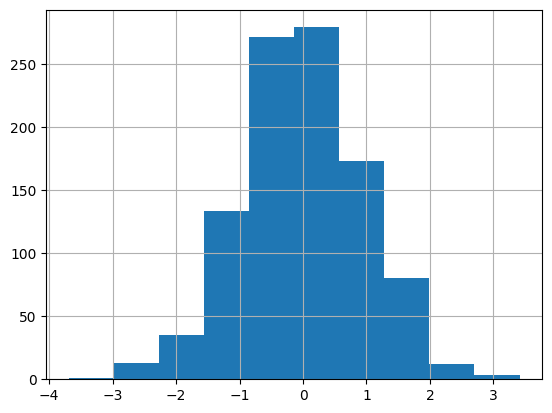

In [5]:
df1['A'].hist()

Call the stylesheet. Let's use the **ggplot** theme:

In [ ]:
plt.style.use('ggplot')

After applying plt.style.use(**ggplot**):

<Axes: >

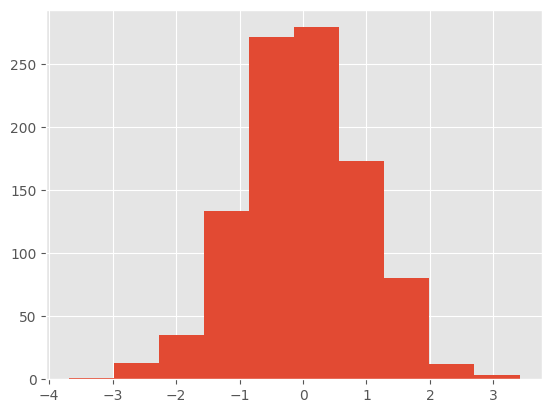

In [7]:
df1['A'].hist()

Now try plt.style.use(**bmh**):

<Axes: >

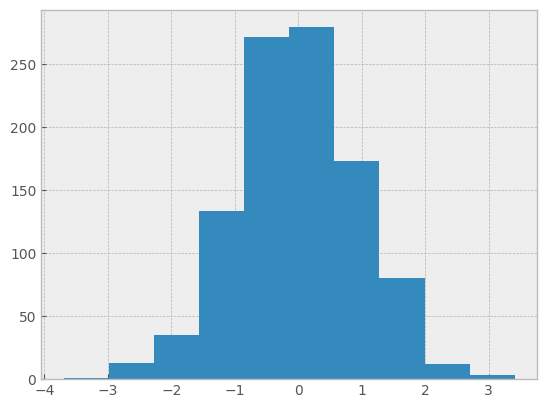

In [8]:
plt.style.use('bmh')
df1['A'].hist()

**fivethirtyeight**

<Axes: >

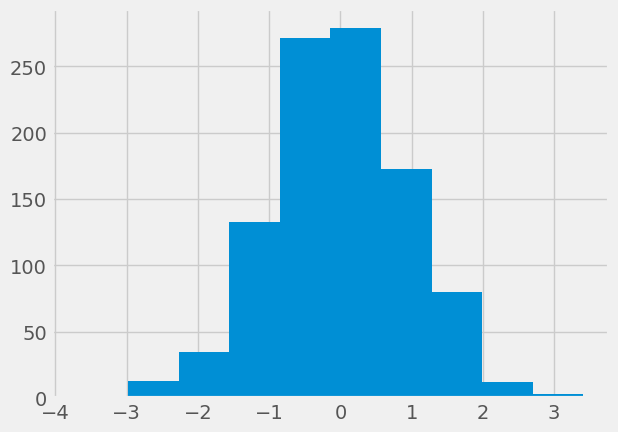

In [9]:
plt.style.use('fivethirtyeight')
df1['A'].hist()

A dark background theme:

<Axes: >

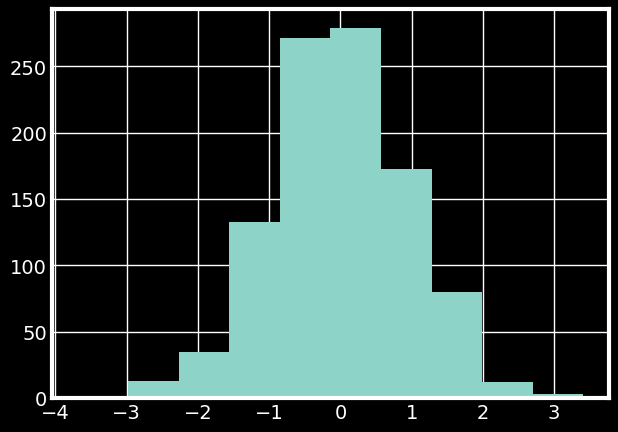

In [10]:
plt.style.use('dark_background')
df1['A'].hist()

Let's stick with the ggplot style for now.

In [11]:
plt.style.use('ggplot')
# plt.style.use('bmh')

## Plot Types

There are several plot types built-in to Pandas, most of them statistical plots by nature:

* df.plot.area     
* df.plot.bar & df.plot.barh         
* df.plot.density  
* df.plot.hist     
* df.plot.line     
* df.plot.scatter
* df.plot.bar      
* df.plot.box      
* df.plot.hexbin   
* df.plot.kde      
* df.plot.pie

Let's call these plot type methods (the key terms shown in the list above, e.g. 'box', 'barh', etc) to see how they work.

In [12]:
### remember the dataframe

df2.head()

,a,b,c,d
0,0.039762,0.218517,0.103423,0.957904
1,0.937288,0.041567,0.899125,0.977680
2,0.780504,0.008948,0.557808,0.797510
3,0.672717,0.247870,0.264071,0.444358
4,0.053829,0.520124,0.552264,0.190008


### Area Plot

<Axes: >

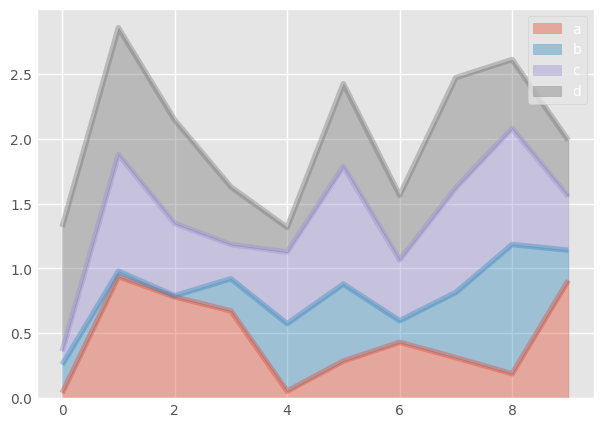

In [13]:
df2.plot.area(alpha=0.4)

### Bar Plots

Bar plots are one of the most common ways to compare categorical data visually. They represent quantities as rectangular bars whose length (or height) corresponds to the value being measured. In Python, these are typically created using *Matplotlib* or *Seaborn*.

Both bar() and barh() create bar charts — the difference is simply orientation. Stacked bar charts, on the other hand, how multiple subcategories contribute to a total within each main category.  

| Plot Type       | Orientation | Purpose                                  | Best For                                |
| --------------- | ----------- | ---------------------------------------- | --------------------------------------- |
| **Bar Plot**    | Vertical    | Compare category values                  | Simple category comparisons             |
| **Barh Plot**   | Horizontal  | Compare category values with long labels | Readability and ranking-type data       |
| **Stacked Bar** | Either      | Show part-to-whole relationships         | Composition of totals across categories |



#### Vertical Bar Plot

<Axes: >

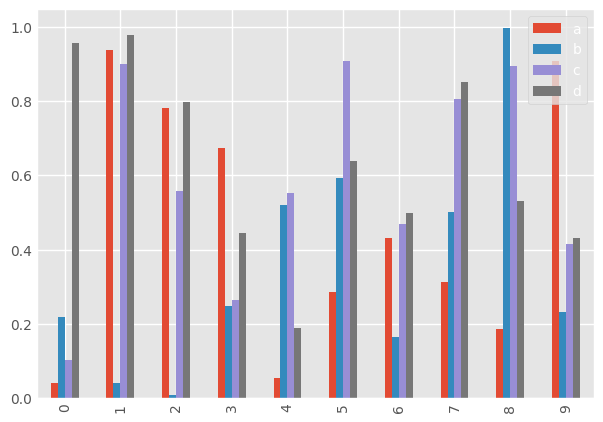

In [14]:
### bar plot

df2.plot.bar()

#### Horizontal Bar Plot 

<Axes: >

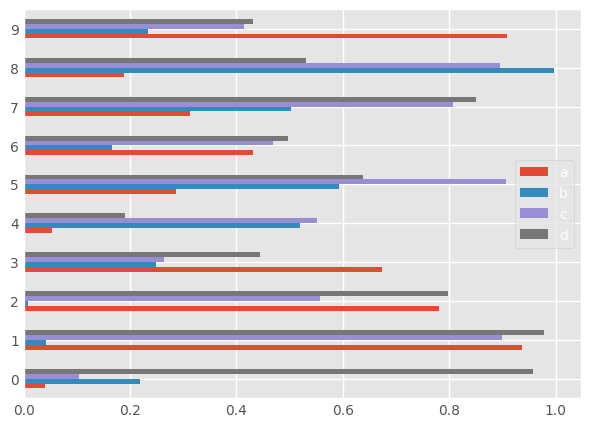

In [15]:
### bar plot horizontal

df2.plot.barh()

<Axes: >

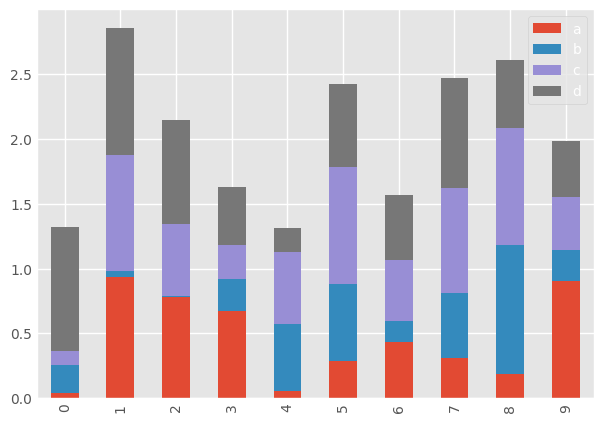

In [16]:
### bar plot stacked

df2.plot.bar(stacked=True)

### Histograms

<Axes: ylabel='Frequency'>

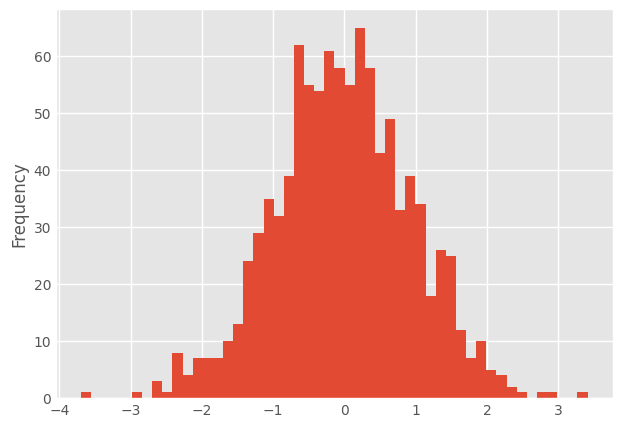

In [17]:
df1['A'].plot.hist(bins=50)

### Line Plots

<Axes: >

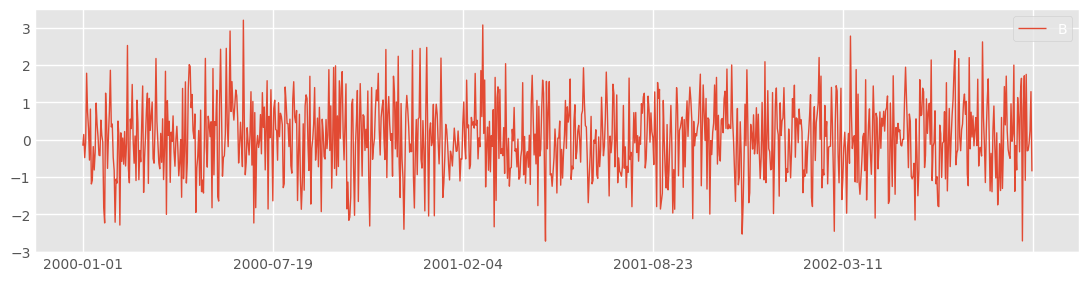

In [18]:
# df1.plot.line(x=df1.index, y='B',figsize=(12,3),lw=1)
df1.plot.line(y='B',figsize=(12,3),lw=1)



### Scatter Plots

<Axes: xlabel='A', ylabel='B'>

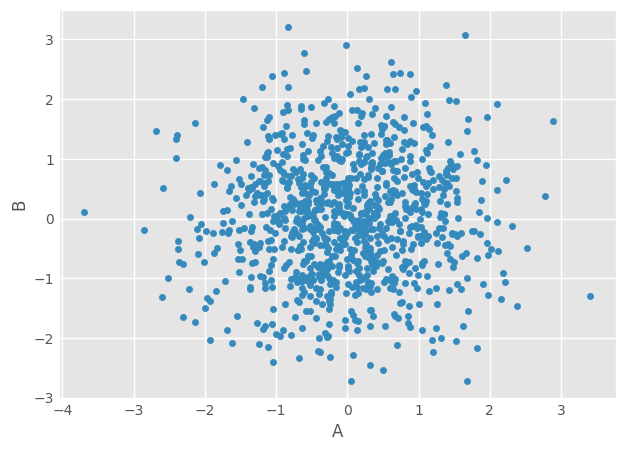

In [19]:
df1.plot.scatter(x='A',y='B')

#### Color Maps
- You can use **c** to color based off another column value. 
- Use **cmap** to indicate colormap to use. 
- For all the colormaps, check out: http://matplotlib.org/users/colormaps.html

<Axes: xlabel='A', ylabel='B'>

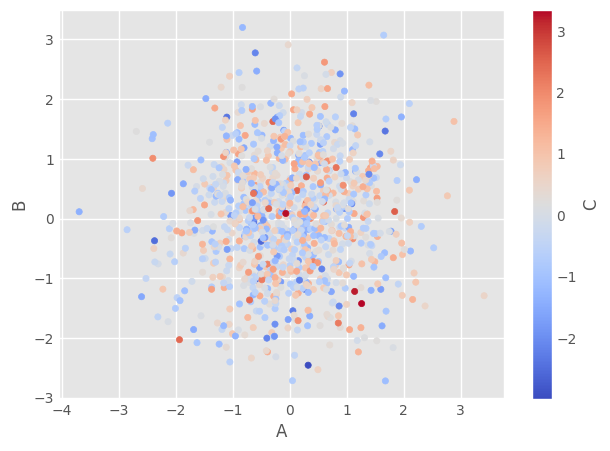

In [20]:
### the color of each point corresponds to the values in column C

# df1.plot.scatter(x=df1['A'], y=df1['B'], c=df1['C'], cmap='coolwarm')  ### color value from 'C'; colormap
df1.plot.scatter(x='A', y='B', c='C', cmap='coolwarm')       ### color value from 'C'; colormap
# df1.plot.scatter(x='A', y='B', c='C', cmap='viridis')      ### another colormap

#### Size

Or use s to indicate size based off another column. s parameter needs to be an array, not just the name of a column:

/Users/tychen/workspace/dsm/.venv/lib/python3.13/site-packages/matplotlib/collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


<Axes: xlabel='A', ylabel='B'>

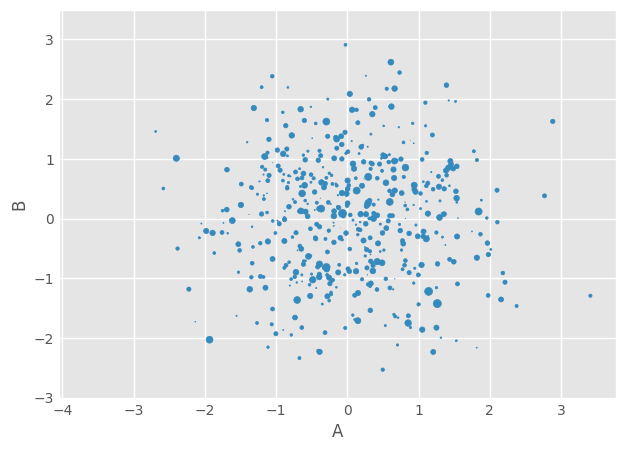

In [21]:
# df1.plot.scatter(x='A', y='B', s=df1['C']*200)
df1.plot.scatter(x='A',y='B',s=df1['C']*10)

### BoxPlots

<Axes: >

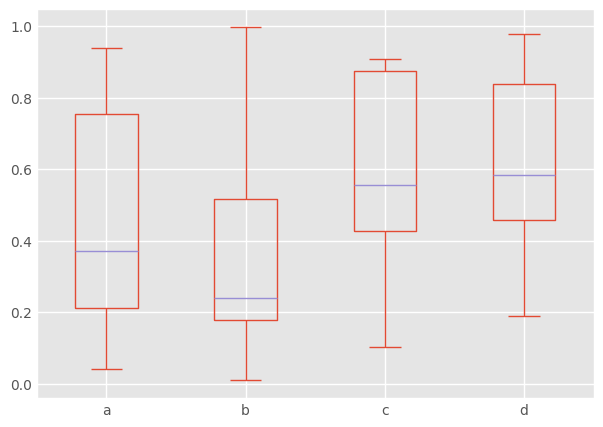

In [22]:
df2.plot.box() # Can also pass a by= argument for groupby

### Hexagonal Bin Plot

Useful for Bivariate Data, alternative to scatterplot:

<Axes: xlabel='a', ylabel='b'>

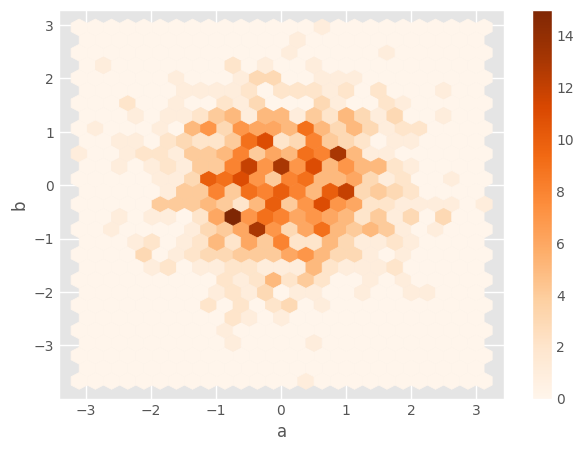

In [23]:
df = pd.DataFrame(np.random.randn(1000, 2), columns=['a', 'b'])
df.plot.hexbin(x='a',y='b',gridsize=25,cmap='Oranges')

### Kernel Density Estimation plot (KDE)

ModuleNotFoundError: No module named 'scipy'

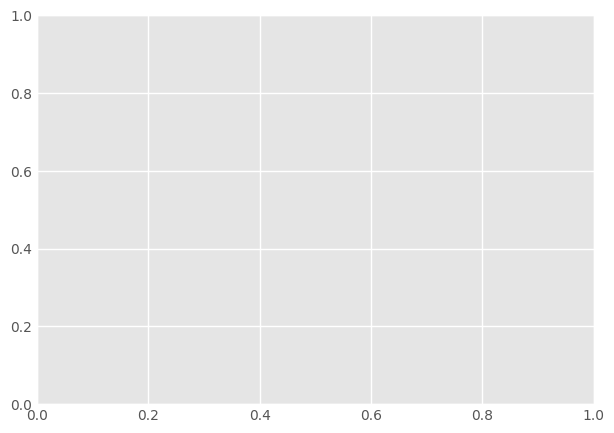

In [ ]:
df2['a'].plot.kde()

<Axes: ylabel='Density'>

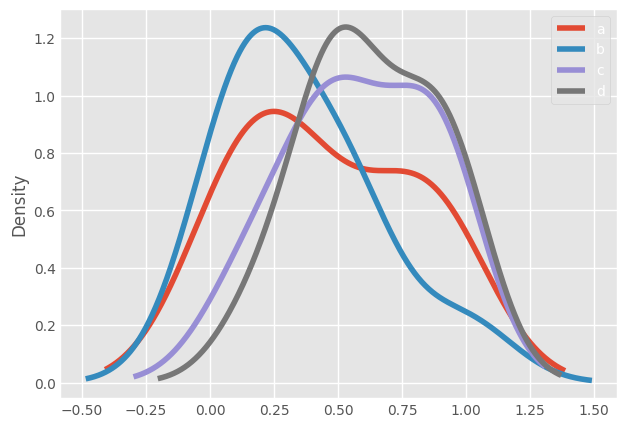

In [ ]:
df2.plot.density()

The end.